# Imports #

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys
from uncertainties import ufloat, unumpy
import os

# Settings
np.set_printoptions(linewidth=200)

# Configuration #

In [120]:
# --- Plotting Style Configuration ---

In [121]:
@dataclass
class PlotParams:
    """
    Container for plot style parameters.
    """
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

## Plotting Logic
Class to handle matplotlib figure creation and saving.

In [122]:
class Plotter:
    """Encapsulates plotting logic for consistent style."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        self.figsize = figsize
        self.fig = None
        self.ax = None
        self.reset(title, xlabel, ylabel)

    def reset(self, title: str, xlabel: str, ylabel: str):
        """Clears the plot and resets styles with new titles. Recreates figure if closed."""
        # Check if figure exists and is active
        if self.fig is None or not plt.fignum_exists(self.fig.number):
            self.fig, self.ax = plt.subplots(figsize=self.figsize)
        else:
            self.ax.cla() # Clear axes
        
        self.ax.set_title(title, fontsize=16, pad=15)
        self.ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
        self.ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
        
        # Re-apply grid and tick settings
        self.ax.minorticks_on()
        self.ax.grid(True, which='major', linestyle='--', alpha=0.5)
        self.ax.grid(True, which='minor', linestyle=':', alpha=0.4)
        self.ax.tick_params(axis='both', which='major', labelsize=12)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker if params.marker else 'none',
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label,
            linestyle='none' # Ensure no line connects points in errorbar mode unless specified
        )

    def finalize_and_show(self, save_path: Optional[str] = None, close_figure: bool = False):
        self.ax.legend(fontsize=12, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")

        plt.show()
        if close_figure:
            plt.close(self.fig)

# Functions #

## Helper Functions for Scientific Reporting
Functions to handle significant figures and LaTeX formatting for paper-ready outputs.

In [8]:
import numpy as np
-int(np.floor(np.log10(abs(0.0005))))

4

In [123]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Rounds value and uncertainty based on the first significant digit of the uncertainty."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

In [124]:
def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Prepares values for scientific notation output.
    Returns: (rounded_val, rounded_sigm, latex_val, latex_sigm, order, relative_error)
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
        scale_order = 0
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

In [125]:
def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """Prints a detailed report for a single parameter including LaTeX format."""
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    if order != 0:
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\ {unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\ {unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\ {unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

In [126]:
def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """Prints summary of fit results."""
    print("="*50)
    print("             APPROXIMATION RESULTS")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)

## Data Processing Functions
Functions for loading data and calculating errors.

In [127]:
def load_data(filename: str, is_unc_x: bool = False, is_unc_y: bool = False):
    """
    Loads data from a text file using numpy.
    Expected format: columns of numbers.
    """
    # Load data using numpy
    data = np.loadtxt(filename)
    
    # Handle different column configurations
    if (is_unc_x and not is_unc_y) or (not is_unc_x and is_unc_y):
        # 3 columns: x, y, err (either x or y)
        return data[:, 0], data[:, 1], data[:, 2]
    if is_unc_x and is_unc_y:
        # 4 columns: x, y, xerr, yerr
        return data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    else:
        # 2 columns: x, y
        return data[:, 0], data[:, 1]

In [128]:
def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """Calculates error arrays based on configuration."""
    err_type = config.get('type')
    xerr, yerr = None, None

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_err')
        yerr = config.get('y_err')
        
    if xerr is None: xerr = np.zeros_like(xdata)
    if yerr is None: yerr = np.zeros_like(ydata)
        
    return xerr, yerr

# Execution #

In [129]:
# --- 1. Define Model Function ---

Define the model function for approximation.
Formula: $f(x) = a \cdot x$

In [130]:
arguments = ['a']

In [131]:
def func_ax(x, a):
    return a * x

In [132]:
# Select function to use
func = func_ax

# Changable parameters #

In [133]:
# type: 'absolute', 'percent', or 'custom'
error_config = {
    'type': 'absolute', 
    'x_val': 0.01, 
    'y_val': 0.2
}

# Execution #

             APPROXIMATION RESULTS
------------ a ------------
Raw value     : 2.4389642268678506 ± 0.06032298470376223
Rounded value : 2.44 ± 0.06
LaTeX: $\left( 2.4400 \pm 0.0600 \right)$ \ ,  $(\varepsilon = 2.46\%)$

Plot saved to: experiment_plot.pdf


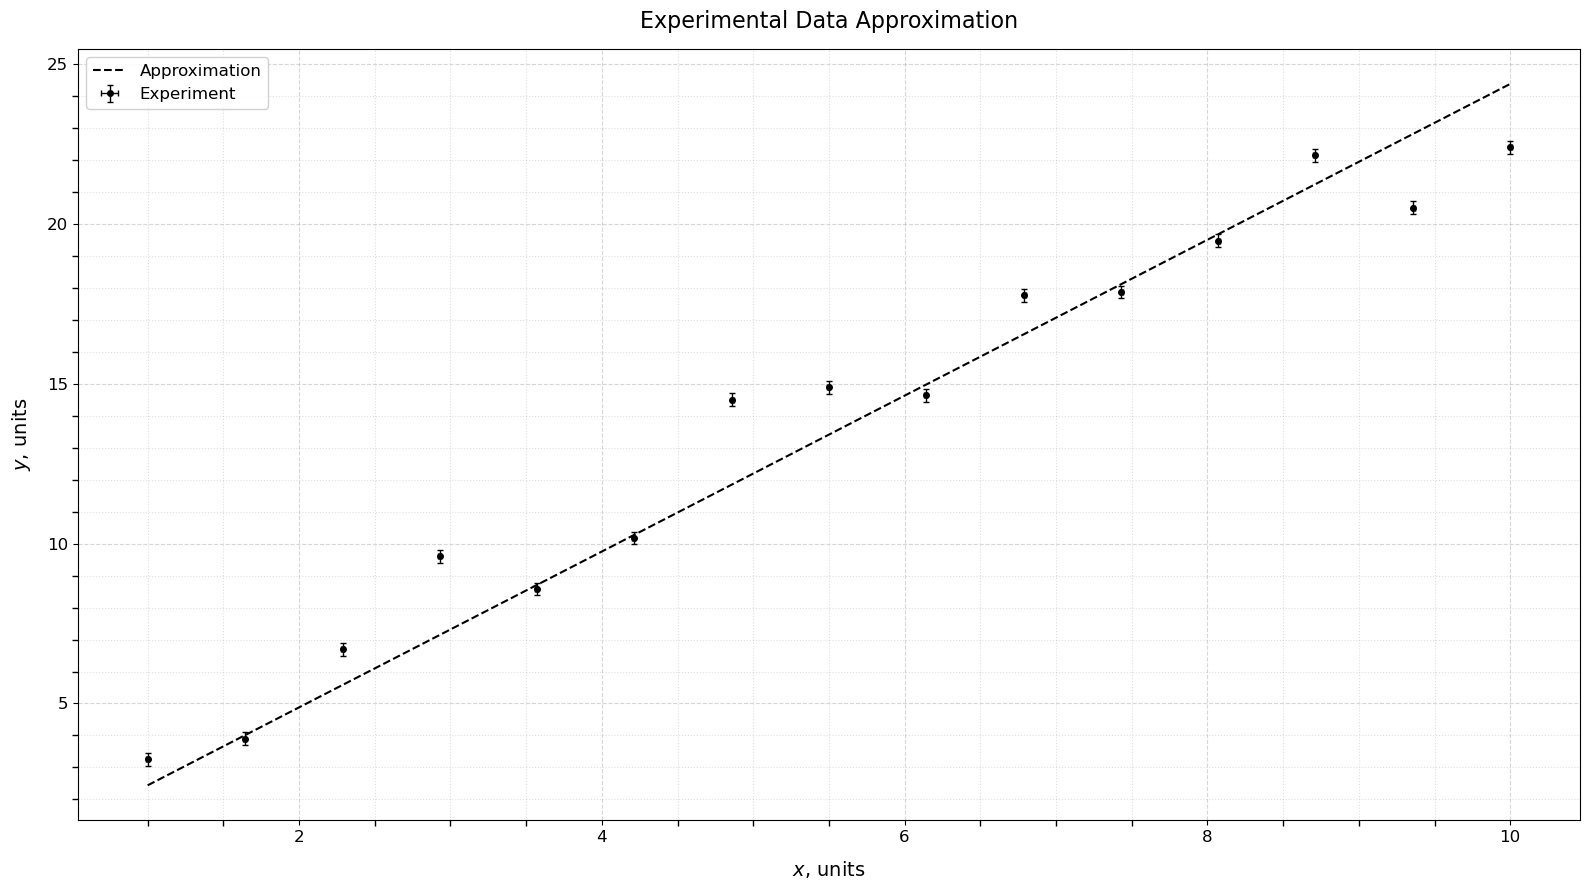

In [134]:
# Use absolute path for robustness
filename = os.path.join('data.txt')

x, y = load_data(filename)

# --- 3. Calculate Errors ---
xerr, yerr = calculate_errors(x, y, error_config)

# --- 4. Approximation ---
# Curve fit
popt, pcov = curve_fit(func, x, y)
perr = np.sqrt(np.diag(pcov))

# Print results
print_fit_summary(arguments, popt, perr)

# --- 5. Visualization ---

# Define plot styles
markevery_i = 1
plot_styles = {
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1.5, label='Approximation'),
    "Error_bars": PlotParams(color="black", linewidth=1.0, marker="o", markersize=4, markevery=markevery_i, capsize=2, label="Experiment"),
}

# Create Plotter
plotter = Plotter(
    title=r'Experimental Data Approximation',
    xlabel=r'$x$, units',
    ylabel=r'$y$, units'
)

# Add experimental data
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_styles['Error_bars'])

# Add fit line
x_smooth = np.linspace(x.min(), x.max(), 500)
y_fit = func(x_smooth, *popt)
plotter.add_fit_line(x_smooth, y_fit, params=plot_styles['Fitted'])

# Save and show
plotter.finalize_and_show("experiment_plot.pdf")

# Execution 2 #